In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("C:/Users/aksha/Documents/Github Datasets/Flight Data/Delayed Flights.csv")

# Preview
print(df.head())

C:\Users\aksha\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\aksha\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


   Date      Month   Value
0     1  1 01 2022  100404
1     2  1 02 2022   94407
2     3  1 03 2022  119574
3     4  1 04 2022  120940
4     5  1 05 2022  120295


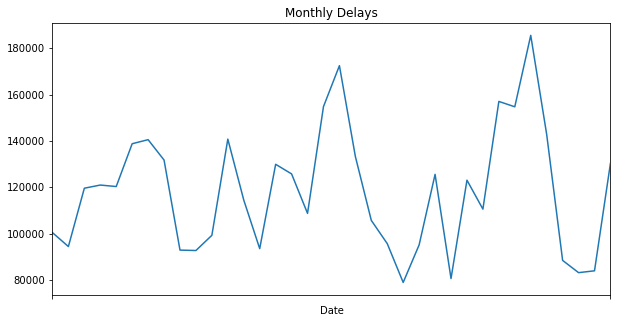

In [2]:
# -----------------------------
# 2. PREPROCESSING
# -----------------------------
# Convert date column (change column name if needed)
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values('Date')

# Set index
df.set_index('Date', inplace=True)

# -----------------------------
# 3. AGGREGATE (Monthly)
# -----------------------------
ts = df['Value']

# Plot
ts.plot(figsize=(10,5), title="Monthly Delays")
plt.show()

In [3]:
# -----------------------------
# 4. CHECK STATIONARITY
# -----------------------------
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(ts)

# Differencing if needed
ts_diff = ts.diff().dropna()

ADF Statistic: -5.314383283889325
p-value: 5.112248446855807e-06


C:\Users\aksha\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
C:\Users\aksha\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
C:\Users\aksha\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                   36
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 12)   Log Likelihood                -263.525
Date:                              Tue, 14 Apr 2026   AIC                            533.049
Time:                                      14:26:02   BIC                            536.456
Sample:                                  01-01-1970   HQIC                           533.906
                                       - 01-01-1970                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.6391      1.098     -0.582      0.560      -2.791       1.513
ma.S.L12       0.27

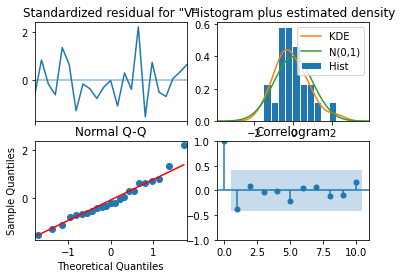

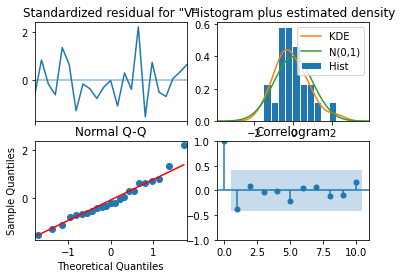

In [4]:
# -----------------------------
# 5. BUILD SARIMA MODEL
# -----------------------------
# You can tune these values
model = SARIMAX(ts,
                order=(0,1,0),        # (p,d,q)
                seasonal_order=(1,1,1,12))  # (P,D,Q,12 for yearly seasonality)

model_fit = model.fit()

print(model_fit.summary())
model_fit.plot_diagnostics()

In [5]:
# -----------------------------
# 6. FORECAST (Next 7 Months)
# -----------------------------
forecast = model_fit.forecast(steps=7)

# Create future dates
future_dates = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1),
                             periods=7, freq='M')

forecast_series = pd.Series(forecast.values)

# -----------------------------
# 7. OUTPUT FORECAST
# -----------------------------
print("Forecast for Jan–Jun 2025:")
print(forecast_series)

Forecast for Jan–Jun 2025:
0    124259.686386
1     86679.073606
2    127281.267573
3    117219.878615
4    139016.898395
5    156476.329930
6    184085.924112
dtype: float64


C:\Users\aksha\AppData\Local\Temp/ipykernel_26300/846470291.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1),
